# EDA of credit card data

Let's start by importing the necessary libraries. For this eda we will import numpy, pandas, matplotlb and seaborn.

In [267]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Now lets work on importing the data from the excel file using pandas. we will store this data in a pandas Data Frame. We will also see 5 random data points of this dataset.

In [268]:
data = pd.read_excel("default of credit card clients.xls", header = 1)
data.sample(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
28092,28093,130000,2,3,2,46,0,0,0,0,...,131866,130707,129174,5000,5000,4600,5000,4614,5139,0
28348,28349,250000,2,1,2,36,0,0,0,0,...,120564,121477,124115,5600,5000,5900,4400,4600,5100,0
18535,18536,250000,2,3,0,26,0,0,0,0,...,83674,64760,52397,129565,10000,3011,3000,2500,2000,0
3913,3914,390000,1,1,1,44,-1,-1,-1,0,...,60616,61357,2798,4711,63701,1214,1241,2812,46220,0
29244,29245,140000,1,2,2,25,1,-1,-1,-1,...,66397,62967,44226,850,2620,66397,2038,2000,15000,0


As you can see the data columns aren't clear. We will name them properly before doing anything else.

This is much more better. now as Id columns is useless, lets drop it.

In [269]:
data = data.drop(columns = 'ID')
data.sample(5)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
3778,230000,1,1,1,39,0,0,0,0,0,...,186989,159345,162695,11200,6200,6237,7000,6000,6100,0
18771,20000,2,2,2,26,-1,-1,-1,-1,-1,...,1119,-222,-222,376,987,1200,0,0,0,1
4903,490000,1,2,1,50,0,0,0,0,0,...,217883,223541,224889,10000,10000,10000,10000,8000,10000,0
19556,30000,2,2,1,29,2,2,2,0,0,...,18416,20099,21631,3175,0,1317,2000,2000,0,1
11469,160000,2,2,1,30,0,0,0,-2,-2,...,694,1800,186,1153,1202,694,1800,186,3573,0


Now let's understand the meaning of the features. After researching, I found that :
- LIMIT_BAL: Amount of the given credit (in NT dollars).
- SEX: Gender (1 = male; 2 = female).
- EDUCATION: Education level (1 = graduate school; 2 = university; 3 = high school; 4 = others; 0, 5, 6 are often grouped into "others/unknown").
- MARRIAGE: Marital status (1 = married; 2 = single; 3 = others).
- AGE: Age in years.
- PAY_0 (or PAY_1), PAY_2, PAY_3, PAY_4, PAY_5, PAY_6: Repayment status for each of the last six months. The values indicate the payment delay:
  - -1 = Pay duly/on time.
  - 0 = No delay.
  - 1 = Payment delay for one month.
  - 2 = Payment delay for two months, etc., up to 9 (nine months and above delay).
- BILL_AMT1 to BILL_AMT6: Amount of bill statement for each of the last six months.
- PAY_AMT1 to PAY_AMT6: Amount of previous payment for each of the last six months.

Now as we know what every feature is, we can explore the data more properly.
Before exploring any feature, lets see if there are any missing values.

In [270]:
data.isna().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

There seems to be no missing data!

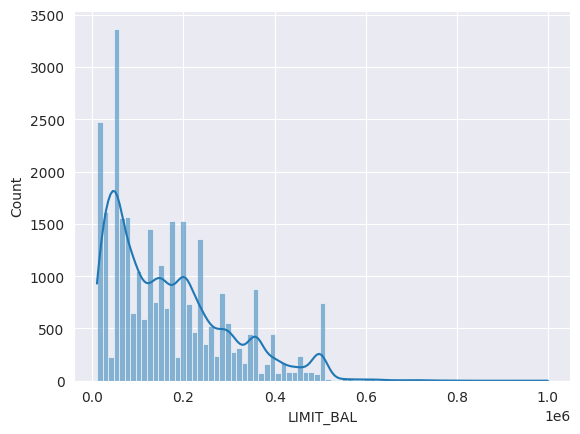

In [271]:
sns.histplot(x = 'LIMIT_BAL', data = data, kde = True)
plt.show()

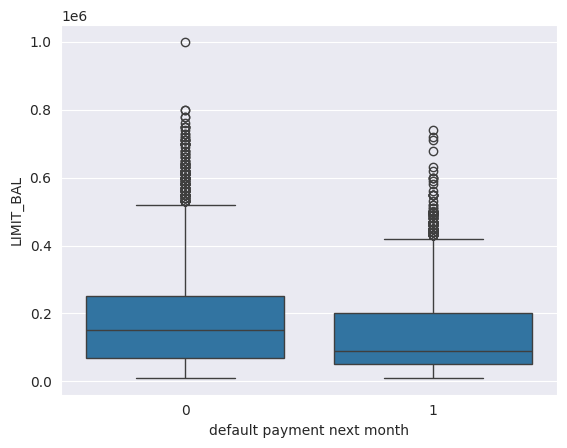

In [272]:
sns.boxplot(y = 'LIMIT_BAL',x = 'default payment next month', data = data)
plt.show()

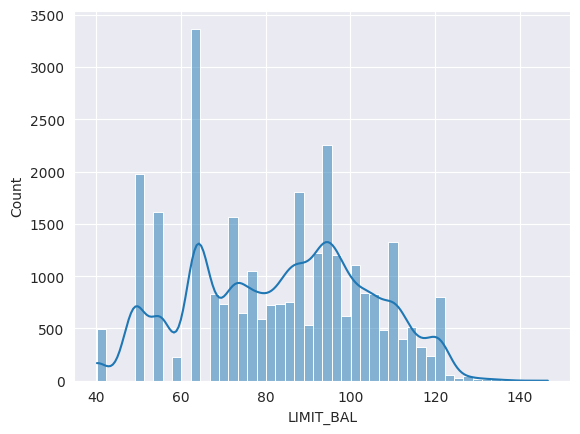

In [273]:
data["LIMIT_BAL"], box_cox_lambda = stats.boxcox(data["LIMIT_BAL"])
sns.histplot(x = 'LIMIT_BAL', data = data, kde = True)
plt.show()

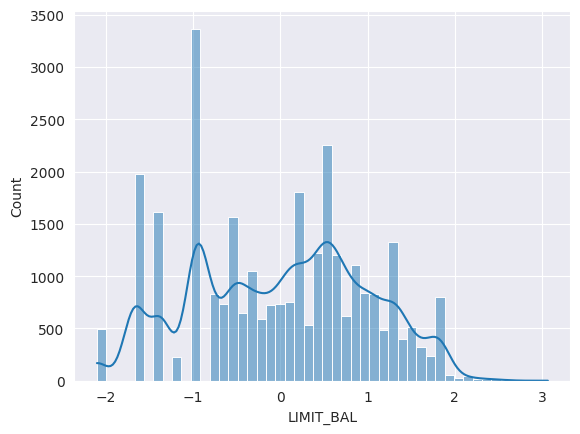

In [274]:
data["LIMIT_BAL"] = (data["LIMIT_BAL"] - data["LIMIT_BAL"].mean())/data["LIMIT_BAL"].std()
sns.histplot(x = 'LIMIT_BAL', data = data, kde = True)
plt.show()

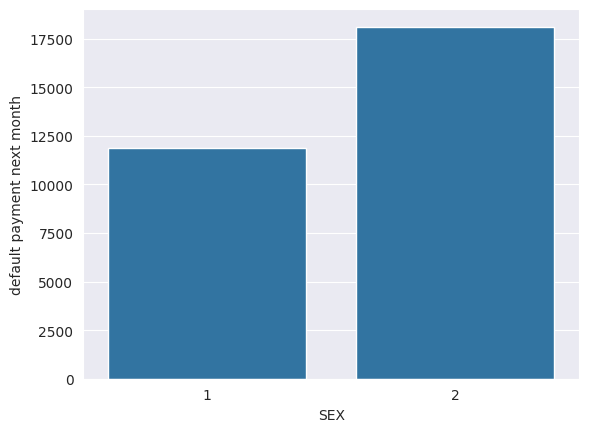

In [275]:
sns.barplot(x = "SEX", y = "default payment next month", data = data, estimator = len)
plt.show()

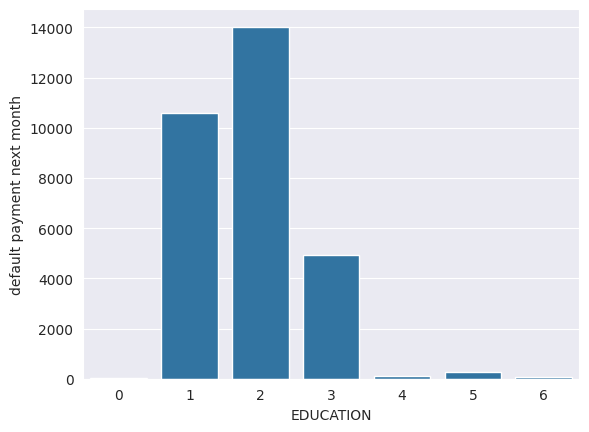

In [276]:
sns.barplot(x = "EDUCATION", y = "default payment next month", data = data, estimator = len)
plt.show()

In [277]:
data["EDUCATION"].value_counts()/len(data["EDUCATION"])

EDUCATION
2    0.467667
1    0.352833
3    0.163900
5    0.009333
4    0.004100
6    0.001700
0    0.000467
Name: count, dtype: float64

In [278]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE

# Step 1: Bucket EDUCATION
data["EDUCATION"] = data["EDUCATION"].replace({5:4, 0:4, 6:4})

# Step 2: Split train/test
train = data[:15000]
test = data[15000:]

X_train = train.drop(columns="default payment next month")
y_train = train["default payment next month"]
X_test = test.drop(columns="default payment next month")
y_test = test["default payment next month"]
smote = SMOTE(sampling_strategy='minority')
X_res, y_res = smote.fit_resample(X_train, y_train)
xgb = XGBClassifier(n_estimators=200, max_depth=4)
xgb.fit(X_res, y_res)
preds_total = xgb.predict(X_test)
print(len(preds_total[preds_total == 1])/len(preds_total))
print(len(y_test[y_test == 1])/len(y_test))
print("Overall test accuracy:", accuracy_score(y_test, preds_total))

0.19613333333333333
0.21726666666666666
Overall test accuracy: 0.7834


In [279]:
from sklearn.metrics import recall_score, f1_score
preds_total = xgb.predict(X_test)

recall_total = recall_score(y_test, preds_total)
f1_total = f1_score(y_test, preds_total)

print("Overall recall:", recall_total)
print("Overall F1-score:", f1_total)


Overall recall: 0.4528996624731513
Overall F1-score: 0.4760522496371553
